### A Framework for Detecting The Onset of Load Saturation in Capacity-Constrained Systems

#### Experiment with Synthetic Data

(C) 2026, Andrei Batyrov [![](ORCID-iD_icon_16x16.png)](https://orcid.org/0009-0001-0370-5378), MSc in Applied Mathematics from HSE University, BEng in Communication Networks and Switching Systems from SibSUTIS, andrey_batyrov@hotmail.com

March 18, 2026

##### <a id="toc"></a>Table of Contents

1. [Synthetic Data](#synth-data)

2. [Trend Estimation](#trend)

3. [Local Moment Estimation](#var-mean)

4. [Local Response Function Estimation](#response)
      
5. [Detection of Saturation](#crit)

6. [Running Framework End-to-End](#framework)

7. [Results](#results)

In [1]:
from pprint import pprint

from ipywidgets import widgets, interact, Layout
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

from pyloadsat import (is_constant, is_monotonic_increasing, has_transition,
                       trend_lowess, window_acf, moments_right, response_lr, plateau_earliest,
                       VRSDetector)
from pyloadsat.data import make_demand_exp, load_carried


In [2]:
# Setup NumPy print format
np.set_printoptions(threshold=10, precision=4)


In [3]:
# Use SVG graphics for smoother plots
%config InlineBackend.figure_format = 'svg'


---
#### <a id="synth-data"></a><div style="font-variant: small-caps">I. Synthetic Data</div>

We generate synthetic incoming load $A_t$ and then apply a service model to convert it to carried load $Y_t$.
As discussed in the Setting and Assumptions subsection, the load is assumed to be:

(1) observed in a system with a constant capacity constraint;

(2) monotonically growing to reflect the underlying demand dynamics;

(3) & (4) transition observable with two operational regimes: elastic followed by saturated.

No assumptions are made in the time domain about load's
- arrival distribution,
- stationarity,
- linearity,
- autocorrelation structure,
- missing values and/or outliers.

Load Model

1. Number of observations: $T$, observation time labels $t \in [1, T]$.
2. Configured constant capacity constraint: $C$.
3. Let incoming load $\hat{A}_t$ reflect monotonic demand growth over time with rate $r$: $\hat{A}_t = \exp[rt]$.
4. Since we do not make any assumptions about arrival distribution, we consider two service models for carried load:
    * Erlang B: $\hat{Y}_t = \hat{A}_t(1 - P_b(\hat{A}_t, C))$.
    * Hard capacity: $\hat{Y}_t = \min(\hat{A}_t, C)$ (not shown in the article).
5. Since we do not make any assumptions about autocorrelation, we add seasonal $\text{AR}(1)_s$ noise $\varepsilon_t = \phi \varepsilon_{t-s} + \eta_t$ to the carried load: $Y_t = \hat{Y}_t + \varepsilon_t$.
7. Missing values and/or outliers are possible.

We first execute the framework algorithm step-by-step and later run the complete framework end-to-end.

In [4]:
T = 1000 # Generate a sample for 1000 observations
t = np.arange(T) # Discrete time labels
rate = 2 / T # Growth rate
demand = make_demand_exp(rate=rate, size=T) # Exponential demand growth model


Uncomment the lines below only if you need to generate new carried load and capacity with Erlang B service model.

In [5]:
# # Erlang B service model
# from pyloadsat.data import make_carried
# phi, w, sigma = 0.3, 10, 0.2
# outliers = 5
# seed = 13
# cap = 0.75
# carried, capacity = make_carried(model='erlangb', demand=demand, cap=cap, ar_noise=(phi, w, sigma), outliers=outliers, seed=seed)
# # Uncomment if you need to save the generated data
# # with open('synth_carried_erlangb.npy', 'wb') as f:
# #     np.save(f, np.stack((carried, capacity), axis=0))


Uncomment the lines below only if you need to generate new carried load and capacity with Hard capacity service model.

In [6]:
# # Hard capacity service model
# from pyloadsat.data import make_carried
# phi, w, sigma = 0.3, 10, 0.2
# outliers = 5
# seed = 13
# cap = 0.6
# carried, capacity = make_carried(model='hardcap', demand=demand, cap=cap, ar_noise=(phi, w, sigma), outliers=outliers, seed=seed)
# # Uncomment if you need to save the generated data
# # with open('synth_carried_hardcap.npy', 'wb') as f:
# #     np.save(f, np.stack((carried, capacity), axis=0))


Otherwise, simply load pre-generated synthetic data.

In [7]:
carried, capacity = load_carried(model='erlangb')
# carried, capacity = load_carried(model='hardcap') # Not shown in the article


Let's take a look at the carried load profile. Note the noisy nature of data with possible missing values and outliers.

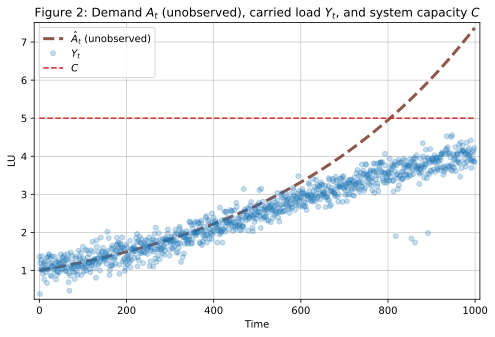

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(demand, ls='--', lw=3, color='C5', label='$\\hat{A}_t$ (unobserved)')
plt.plot(carried, lw=0, marker='o', markersize=5, color='C0', alpha=0.25, label='$Y_t$')
plt.plot(capacity, lw=1.5, ls='--', color='C3', label='$C$')
plt.scatter(t.min(), carried.min(), marker='none')
plt.xlabel('Time')
plt.ylabel('LU')
plt.title('Figure 2: Demand $A_t$ (unobserved), carried load $Y_t$, and system capacity $C$')
plt.margins(x=0.012, y=0.02)
plt.gca().set_axisbelow(True)
plt.grid(lw=0.5)
plt.legend(loc='upper left', fontsize=10)
plt.show();


We observe that the hypothetical incoming load exceeds the system capacity, while the observed served load exhibits saturation. According to the theorem, this necessarily induces an unknown critical point $t^*$ separating the elastic and saturated regimes, which forms the basis for the subsequent detection. Before $t^*$ the carried load $Y_t$ is a good proxy of incoming demand $A_t$. However, after that transition point the carried load becomes saturated and does not reflect genuine demand dynamics any longer.

Check Assumption (1): Constant capacity constraint $C_t = C, \forall t$.

In [9]:
constant_status = is_constant(capacity)
if constant_status:
    print('Constant capacity constraint is met, continue.')
else:
    raise RuntimeError('Constant capacity constraint is not met, stop.')


Constant capacity constraint is met, continue.


[TOC](#toc)

---
##### <a id="trend"></a><div style="font-variant: small-caps">II. Trend Estimation</div>

We use `statsmodels` implementation of LOWESS where the span is configured as a fraction of the number of all observations.

As discussed in the Sensitivity Analysis section, we use the default smoothing span $f = 2/3$. We also do sensitivity analysis to verify that alternative span values produce qualitatively similar results.

In [10]:
frac = 2. / 3
frac_min = 1. / T # One observation
frac_max = 1.0 # All data


In [ ]:
@interact(frac=widgets.FloatSlider(min=frac_min, max=frac_max, step=0.01, value=2./3, description='LOWESS span frac', 
                                    style={'description_width': '20%'}, layout=Layout(width='50%')
                                    ))
def choose_tau(frac):
    trend = trend_lowess(carried, frac=frac)
    plt.figure(figsize=(8, 5))
    plt.plot(carried, lw=0, marker='o', markersize=5, color='C0', alpha=0.25, label='$Y_t$')
    plt.plot(trend, ls='--', lw=3, color='C4', label='$\\hat{Y}_t$')
    # plt.plot(capacity, lw=1.5, ls='--', color='C3', label='$C$')
    plt.xlabel('Time')
    plt.ylabel('LU')
    plt.title('Carried load with estimated trend (not shown in the article)')
    plt.gca().set_axisbelow(True)
    plt.grid(lw=0.5)
    plt.legend(loc='upper left', fontsize=11)
    plt.show();


interactive(children=(FloatSlider(value=0.6666666666666666, description='LOWESS span frac', layout=Layout(widt…

Finally, looking at the estimated trend for $f = 2/3$.

In [12]:
trend = trend_lowess(carried, frac=frac)
print(f'{trend = }')


trend = array([0.9443, 0.9472, 0.95  , ..., 4.1323, 4.1354, 4.1385], shape=(1000,))


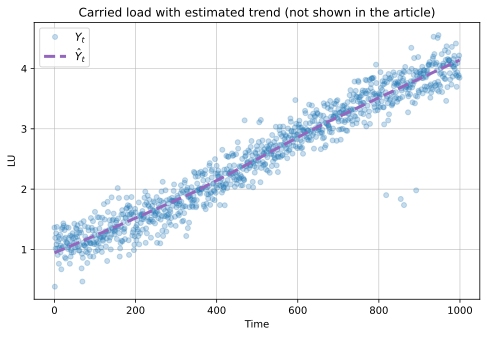

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(carried, lw=0, marker='o', markersize=5, color='C0', alpha=0.25, label='$Y_t$')
plt.plot(trend, ls='--', lw=3, color='C4', label='$\\hat{Y}_t$')
# plt.plot(capacity, ls='--', color='C3', label='$C$')
plt.xlabel('Time')
plt.ylabel('LU')
plt.title('Carried load with estimated trend (not shown in the article)')
plt.legend(loc='upper left', fontsize=11)
plt.gca().set_axisbelow(True)
plt.grid(lw=0.5)
plt.show();


The estimated trend is robust to noise and outliers, whereas still preserving the regime shift information.

Check Assumption (2): Monotonic demand growth. As discussed in the Sensitivity Analysis section, $p_0 = 0.8$.

In [14]:
p_0 = 0.8
monotonic_status, _ = is_monotonic_increasing(trend, p_0)
if monotonic_status:
    print('Trend is monotonically increasing, continue.')
else:
    raise RuntimeError('Trend is not monotonically increasing, stop.')


Trend is monotonically increasing, continue.


[TOC](#toc)

---
##### <a id="var-mean"></a><div style="font-variant: small-caps">III. Local Moment Estimation</div>

As discussed in the Sensitivity Analysis section, we estimate the local moment window size from the detrended load ACF and set it equal to the longest lag, or 2 if no significant autocorrelation is found.

In [15]:
acf, acf_peaks, w = window_acf(carried - trend)
print(f'{w = }')


w = 30


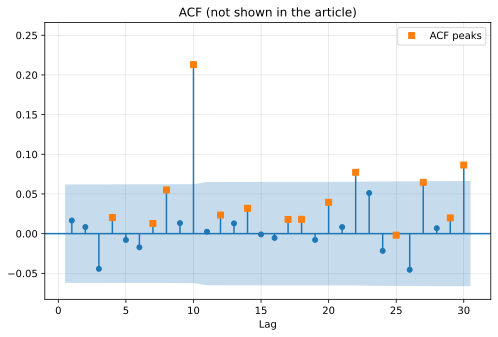

In [16]:
_, ax_acf = plt.subplots(figsize=(8, 5))
plot_acf(carried - trend, zero=False, auto_ylims=True, use_vlines=True, missing='drop', alpha=0.05, 
         title='ACF (not shown in the article)', ax=ax_acf)
ax_acf.plot(acf[0] * acf_peaks, lw=0, marker='s', color='C1', label='ACF peaks')
ax_acf.set_xlabel('Lag')
plt.gca().set_axisbelow(True)
ax_acf.grid(lw=0.25)
ax_acf.legend(loc='upper right')
plt.show();


We use the estimated trend and window size to estimate the sequence of pairs of local means and local variances $\{\operatorname{\mathbb{E}}_i[\hat{Y}], \operatorname{Var}_i[\hat{Y}]\}$.

In [17]:
means, variances, mean_max = moments_right(trend, window=w)
print(f'{means = }\n{variances = }')


means = array([   nan,    nan,    nan, ..., 4.0875, 4.0906, 4.0937], shape=(1000,))
variances = array([   nan,    nan,    nan, ..., 0.0007, 0.0007, 0.0007], shape=(1000,))


Let's take a look at the variance-mean relationship.

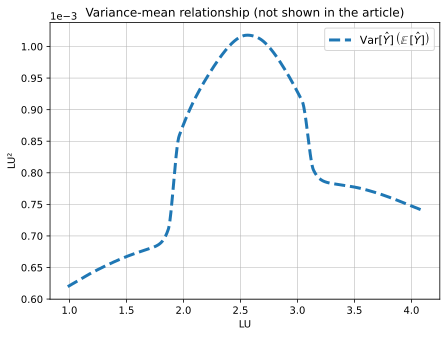

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(means, variances, ls='--', lw=3, color='C0', 
         label='$\\operatorname{Var[\\hat{Y}]}\\left(\\operatorname{\\mathbb{E}}[\\hat{Y}]\\right)$')
plt.xlabel('LU')
plt.ylabel('LU²')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.title('Variance-mean relationship (not shown in the article)')
plt.legend(loc='upper right', fontsize=11)
plt.gca().set_axisbelow(True)
plt.grid(lw=0.5)
plt.show();


Check Assumptions (3) & (4): Transition observability. As discussed in the Sensitivity Analysis section, the system is transition-observable if
$\operatorname{\mathbb{E}}_{\max}[\hat{Y}] \in [q_{0.35}, q_{0.65}]$.

In [19]:
print(f'{mean_max = :.2f}')


mean_max = 2.56


In [20]:
q_lower, q_upper = 0.35, 0.65 # core around median
transition_status, transition_regime, means_lower, means_upper = has_transition(means, mean_max, q_lower, q_upper)
print(f'{transition_status = }\n{means_lower = :.2f}, {means_upper = :.2f}')


transition_status = True
means_lower = 1.99, means_upper = 3.02


In [21]:
means_hist_y, means_hist_x = np.histogram(means[~np.isnan(means)], bins=30, density=True)
means_hist_x = means_hist_x[:-1]


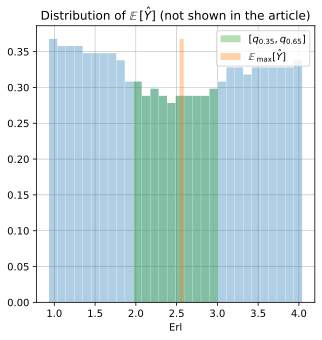

In [22]:
plt.figure(figsize=(5, 5))
plt.bar(means_hist_x, means_hist_y, width=0.1, color='C0', alpha=0.35)
plt.bar(means_hist_x[(means_hist_x >= means_lower) & (means_hist_x <= means_upper)], 
        means_hist_y[(means_hist_x >= means_lower) & (means_hist_x <= means_upper)], 
        width=0.1, color='C2', alpha=0.35, label=f'$[q_{{{q_lower}}}, q_{{{q_upper}}}]$')
plt.bar(mean_max, means_hist_y.max(), width=0.05, color='C1', alpha=0.35, 
        label='$\\operatorname{\\mathbb{E}}_{\\max}[\\hat{Y}]$')
plt.xlabel('Erl')
plt.title('Distribution of $\\operatorname{\\mathbb{E}}[\\hat{Y}]$ (not shown in the article)')
plt.legend()
plt.gca().set_axisbelow(True)
plt.grid(lw=0.5)
plt.show();


In [23]:
if transition_status:
    print('Regime transition is identifiable, continue.')
else:
    raise RuntimeError(f'Regime transition is not identifiable: {transition_regime}, stop.')


Regime transition is identifiable, continue.


[TOC](#toc)

---
##### <a id="response"></a><div style="font-variant: small-caps">IV. Local Response Function Estimation</div>

We use `statsmodels` implementation of rolling linear regression to compute $\mathcal{R} \approx \beta^{(LR)}$. As discussed in the Sensitivity Analysis section, we use ROT to estimate the bandwidth $h = \lfloor k T^{-1/5} \rfloor$. We do sensitivity analysis to find $k$.

In [24]:
k_min, k_max = 2 * T ** (1/5) + 1e-9, T ** (6/5)
print(f'{k_min = :.2f}, {k_max = :.2f}')


k_min = 7.96, k_max = 3981.07


In [25]:
@interact(k=widgets.FloatSlider(min=k_min, max=k_max, step=1.0, value=k_min, description='Bandwidth parameter k', 
                                    style={'description_width': '30%'}, layout=Layout(width='50%')
                                    ))
def choose_w(k):
    response = response_lr(y=variances, X=means, bandwidth=k)
    plt.figure(figsize=(7, 5))
    plt.plot(means, variances, ls='--', lw=3, color='C0', 
             label='$\\operatorname{Var[\\hat{Y}]}\\left(\\operatorname{\\mathbb{E}}[\\hat{Y}]\\right)$')
    plt.xlabel('LU')
    plt.ylabel('LU²')
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.title('Variance-mean relationship $\\operatorname{Var[\\hat{Y}]}\\left(\\operatorname{\\mathbb{E}}[\\hat{Y}]\\right)$ and response function $\\mathcal{R}$ estimated via local response parameter $\\beta^{(LR)}$')
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(axis='x', lw=0.5)
    ax2 = plt.gca().twinx()
    ax2.plot(means, response, lw=0, marker='.', markersize=5, color='C5', alpha=0.75, 
             label='$\\beta^{(LR)}$')
    ax2.set_ylabel('LU')
    ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax2.legend(loc='upper right', fontsize=11)
    plt.gca().set_axisbelow(True)
    ax2.grid(axis='y', lw=0.5)
    plt.show();


interactive(children=(FloatSlider(value=7.9621434120699455, description='Bandwidth parameter k', layout=Layout…

We observe the prominent extremum (maximum) of the variance-mean relationship and the sign change of the response function.
We can adjust the robustness of the linear regression estimator to noise by changing the bandwidth $h$ which may incur a delay in reporting its sign change. This therefore may shift $t^*$ to the right, i.e. incur a delay in reporting the onset of load saturation.
We choose $k = T / 3$ as a reasonable trade-off between ensuring robustness while minimizing delay.

In [26]:
k = T / 3
h = int(np.floor(k * T ** (-1/5)))
print(f'{k = :.2f}, {h = }')


k = 333.33, h = 83


Finally, looking at the estimated local response function for $h$.

In [27]:
response = response_lr(y=variances, X=means, bandwidth=h)
if response is None:
    raise RuntimeError('Response function cannot be estimated, stop.')
print(f'{response = }')


response = array([        nan,         nan,         nan, ..., -7.2199e-05,
       -7.2233e-05, -7.2263e-05], shape=(1000,))


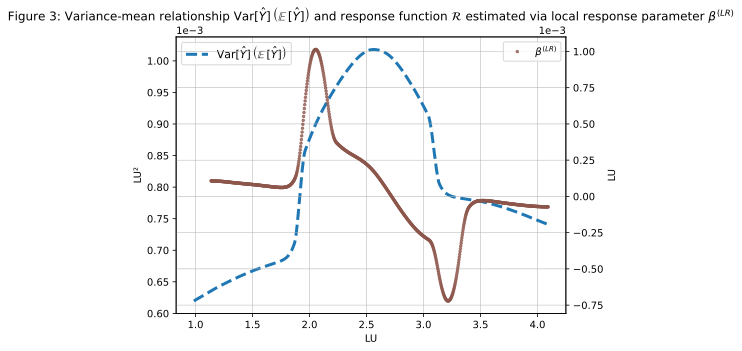

In [28]:
plt.figure(figsize=(7, 5))
plt.plot(means, variances, ls='--', lw=3, color='C0', 
            label='$\\operatorname{Var[\\hat{Y}]}\\left(\\operatorname{\\mathbb{E}}[\\hat{Y}]\\right)$')
plt.xlabel('LU')
plt.ylabel('LU²')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.title('Figure 3: Variance-mean relationship $\\operatorname{Var[\\hat{Y}]}\\left(\\operatorname{\\mathbb{E}}[\\hat{Y}]\\right)$ and response function $\\mathcal{R}$ estimated via local response parameter $\\beta^{(LR)}$')
plt.legend(loc='upper left', fontsize=11)
plt.grid(axis='x', lw=0.5)
ax2 = plt.gca().twinx()
ax2.plot(means, response, lw=0, marker='.', markersize=5, color='C5', alpha=0.75, 
         label='$\\beta^{(LR)}$')
ax2.set_ylabel('LU')
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.legend(loc='upper right', fontsize=10)
plt.gca().set_axisbelow(True)
ax2.grid(axis='y', lw=0.5)
plt.show();


[TOC](#toc)

---
##### <a id="crit"></a><div style="font-variant: small-caps">V. Detection of Saturation

We classify the regimes as follows:
1. $\beta^{(LR)} > 0$, elastic regime, variance responds proportionally to increases in load level.
2. $\beta^{(LR)} \leq 0$, saturated regime, variance decreases or stagnates as load grows.

The transition time $t^*$ is the earliest time when a persistent plateau $\beta^{(LR)} \leq 0$ in the sequence $\{\beta^{(LR)}\}$ is established. As discussed in the Sensitivity Analysis section, the length of the sought plateau $l \in [w, T]$. We start from the smallest $l$ and increase it, until the longest contiguous plateau is found.

In [29]:
t_crit = -1
for l in range(w, T + 1, w):
    t_crit_l = plateau_earliest((response <= 0.), l)
    t_crit = max(t_crit, t_crit_l)
    # print(l, t_crit_l)
if t_crit == -1:
    raise RuntimeError(f'No persistent plateau of length {l} found, stop.')


In [30]:
carried_crit = means[t_crit]
print(f'{t_crit = }\n{carried_crit = :.2f}')


t_crit = 576
carried_crit = 2.72


Label the carried load, as per the identified regimes.

In [31]:
carried_elastic = carried[:t_crit]
carried_saturated = carried[t_crit:]


Finally, we can report the identified $t^*$ and $Y^*$ and show the labeled carried load.

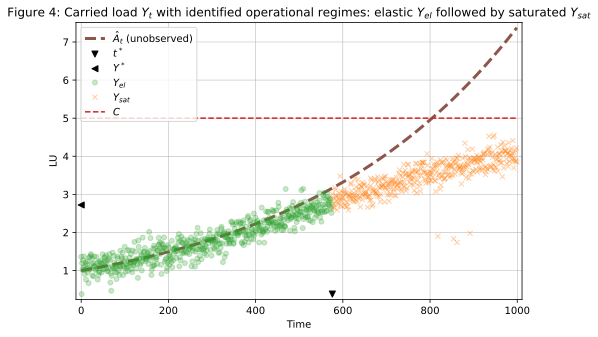

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(demand, ls='--', lw=3, color='C5', label='$\\hat{A}_t$ (unobserved)')
plt.scatter(t_crit, carried.min(), color='black', marker='v', label='$t^*$')
plt.scatter(t.min(), carried_crit, color='black', marker='<', label='$Y^*$')
plt.plot(t[:t_crit], carried_elastic, lw=0, marker='o', markersize=5, color='C2', alpha=0.25, label='$Y_{el}$')
plt.plot(t[t_crit:], carried_saturated, lw=0, marker='x', markersize=5, color='C1', alpha=0.375, label='$Y_{sat}$')
plt.plot(capacity, lw=1.5, ls='--', color='C3', label='$C$')
plt.xlabel('Time')
plt.ylabel('LU')
plt.title('Figure 4: Carried load $Y_t$ with identified operational regimes: elastic $Y_{el}$ followed by saturated $Y_{sat}$')
plt.margins(x=0.012, y=0.02)
plt.gca().set_axisbelow(True)
plt.grid(lw=0.5)
plt.legend(loc='upper left', fontsize=10)
plt.show();


[TOC](#toc)

---
##### <a id="framework"></a><div style="font-variant: small-caps">VI. Running Framework End-to-End

Here we run the complete framework to produce identical results of the load saturation detection as in the step-by-step implementation above.

In [33]:
# 1. Create a detector
detector = VRSDetector('synth')
# Detector is initialized
pprint(detector.summary(), sort_dicts=False)


{<class 'pyloadsat.vrsd.Detector'>: {'name': 'synth',
                                     'frac': 0.6666666666666666,
                                     'p_0': 0.8,
                                     'window': None,
                                     'nlags': None,
                                     'alpha': 0.05,
                                     'q_lower': 0.35,
                                     'q_upper': 0.65,
                                     'bandwidth': None,
                                     '_trend': None,
                                     '_means': None,
                                     '_variances': None,
                                     '_mean_max': None,
                                     '_response': None,
                                     '_t_crit': None,
                                     '_load_crit': None,
                                     '_length': None,
                                     'fitted': False,
                 

In [34]:
# 2. Fit the detector on our data: estimate trend, local moments, and local response function
detector.fit(carried)
# Detector is fitted
pprint(detector.summary(), sort_dicts=False)


{<class 'pyloadsat.vrsd.Detector'>: {'name': 'synth',
                                     'frac': 0.6666666666666666,
                                     'p_0': 0.8,
                                     'window': 30,
                                     'nlags': None,
                                     'alpha': 0.05,
                                     'q_lower': 0.35,
                                     'q_upper': 0.65,
                                     'bandwidth': None,
                                     '_trend': array([0.9443, 0.9472, 0.95  , ..., 4.1323, 4.1354, 4.1385], shape=(1000,)),
                                     '_means': array([   nan,    nan,    nan, ..., 4.0875, 4.0906, 4.0937], shape=(1000,)),
                                     '_variances': array([   nan,    nan,    nan, ..., 0.0007, 0.0007, 0.0007], shape=(1000,)),
                                     '_mean_max': np.float64(2.5623746335921274),
                                     '_response': array

In [35]:
# 3. Identify the critical point
detect_status, t_crit, load_crit = detector.detect()
print(f'{detect_status = }\n{t_crit = }\n{load_crit = }')
# Final state of the detector
pprint(detector.summary(), sort_dicts=False)


detect_status = True
t_crit = 576
load_crit = np.float64(2.7214923997010545)
{<class 'pyloadsat.vrsd.Detector'>: {'name': 'synth',
                                     'frac': 0.6666666666666666,
                                     'p_0': 0.8,
                                     'window': 30,
                                     'nlags': None,
                                     'alpha': 0.05,
                                     'q_lower': 0.35,
                                     'q_upper': 0.65,
                                     'bandwidth': None,
                                     '_trend': array([0.9443, 0.9472, 0.95  , ..., 4.1323, 4.1354, 4.1385], shape=(1000,)),
                                     '_means': array([   nan,    nan,    nan, ..., 4.0875, 4.0906, 4.0937], shape=(1000,)),
                                     '_variances': array([   nan,    nan,    nan, ..., 0.0007, 0.0007, 0.0007], shape=(1000,)),
                                     '_mean_max': np.float64

[TOC](#toc)

---
##### <a id="results"></a><div style="font-variant: small-caps">VII. Results

We have identified two operational regimes of the system:
* Elastic in which the carried load is a reliable proxy of the incoming load; demand forecasting is admissible.
* Saturated in which the carried load does not convey the genuine demand dynamics; capacity expansion is recommended.

> An important empirical observation is that $Y^* < C$. This indicates that the onset of load saturation is not tied to the configured capacity limit itself, but rather reflects an earlier loss of load elasticity. Such behavior highlights the diagnostic value of the proposed framework in revealing latent saturation effects that are not captured by static capacity parameters.

[TOC](#toc)